# Рубежный контроль №1 (весна 2026)
**Студент:** Королев А.С.  
**Группа:** ИУ5Ц-81Б  
**Вариант:** 26 (Задача №4, набор №2 - Wine)  

**Доп. требование (ИУ5Ц-81Б):** Диаграмма рассеяния

# Импорт и проверка


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

# Проверка версий
print(f"Pandas: {pd.__version__}")
print(f"Seaborn: {sns.__version__}")

# Настройка графиков
%matplotlib inline
sns.set_theme(style="whitegrid")

Pandas: 3.0.2
Seaborn: 0.13.2


# Загрузка данных

In [2]:
# Загрузка датасета Wine
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Размер данных: {df.shape}")
print(f"\nПропуски:\n{df.isnull().sum()}")
df.head()

Размер данных: (178, 14)

Пропуски:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Обработка пропусков

In [3]:
# ============================================
# ИСКУССТВЕННОЕ СОЗДАНИЕ ДАННЫХ (по требованию Примечаний)
# ============================================

print("="*60)
print("СОЗДАНИЕ ИСКУССТВЕННЫХ ДАННЫХ (по требованию Примечаний)")
print("="*60)

# 1. Создаём категориальный признак на основе числового
df['alcohol_category'] = pd.cut(df['alcohol'], 
                                  bins=[0, 12, 13.5, 20], 
                                  labels=[1, 2, 3])
print("\n1. Создан категориальный признак 'alcohol_category' на основе 'alcohol':")
print(df['alcohol_category'].value_counts())

# 2. Создаём пропуски в числовом признаке (10%)
np.random.seed(42)
mask = np.random.random(len(df)) < 0.1
df.loc[mask, 'malic_acid'] = np.nan

print(f"\n2. Созданы пропуски в 'malic_acid': {df['malic_acid'].isnull().sum()} шт. ({df['malic_acid'].isnull().sum()/len(df)*100:.1f}%)")

# 3. Создаём пропуски в категориальном признаке (5%)
mask_cat = np.random.random(len(df)) < 0.05
df.loc[mask_cat, 'alcohol_category'] = np.nan

print(f"\n3. Созданы пропуски в 'alcohol_category': {df['alcohol_category'].isnull().sum()} шт. ({df['alcohol_category'].isnull().sum()/len(df)*100:.1f}%)")

print("\nИскусственные данные созданы.")

СОЗДАНИЕ ИСКУССТВЕННЫХ ДАННЫХ (по требованию Примечаний)

1. Создан категориальный признак 'alcohol_category' на основе 'alcohol':
alcohol_category
2    101
3     55
1     22
Name: count, dtype: int64

2. Созданы пропуски в 'malic_acid': 21 шт. (11.8%)

3. Созданы пропуски в 'alcohol_category': 12 шт. (6.7%)

Искусственные данные созданы.


In [4]:
print("="*60)
print("ОБРАБОТКА ПРОПУСКОВ (по требованию ТЗ)")
print("="*60)

print(f"Размер ДО удаления: {df.shape}")
print(f"Пропуски:\n{df.isnull().sum()}")

# Удаляем строки с пропусками
df_cleaned = df.dropna()

print(f"\nРазмер ПОСЛЕ удаления: {df_cleaned.shape}")
print(f"Удалено строк: {df.shape[0] - df_cleaned.shape[0]}")

df = df_cleaned
print("\n Данные очищены, можно строить графики.")

ОБРАБОТКА ПРОПУСКОВ (по требованию ТЗ)
Размер ДО удаления: (178, 15)
Пропуски:
alcohol                          0
malic_acid                      21
ash                              0
alcalinity_of_ash                0
magnesium                        0
total_phenols                    0
flavanoids                       0
nonflavanoid_phenols             0
proanthocyanins                  0
color_intensity                  0
hue                              0
od280/od315_of_diluted_wines     0
proline                          0
target                           0
alcohol_category                12
dtype: int64

Размер ПОСЛЕ удаления: (145, 15)
Удалено строк: 33

 Данные очищены, можно строить графики.


# график 1: гистограммы

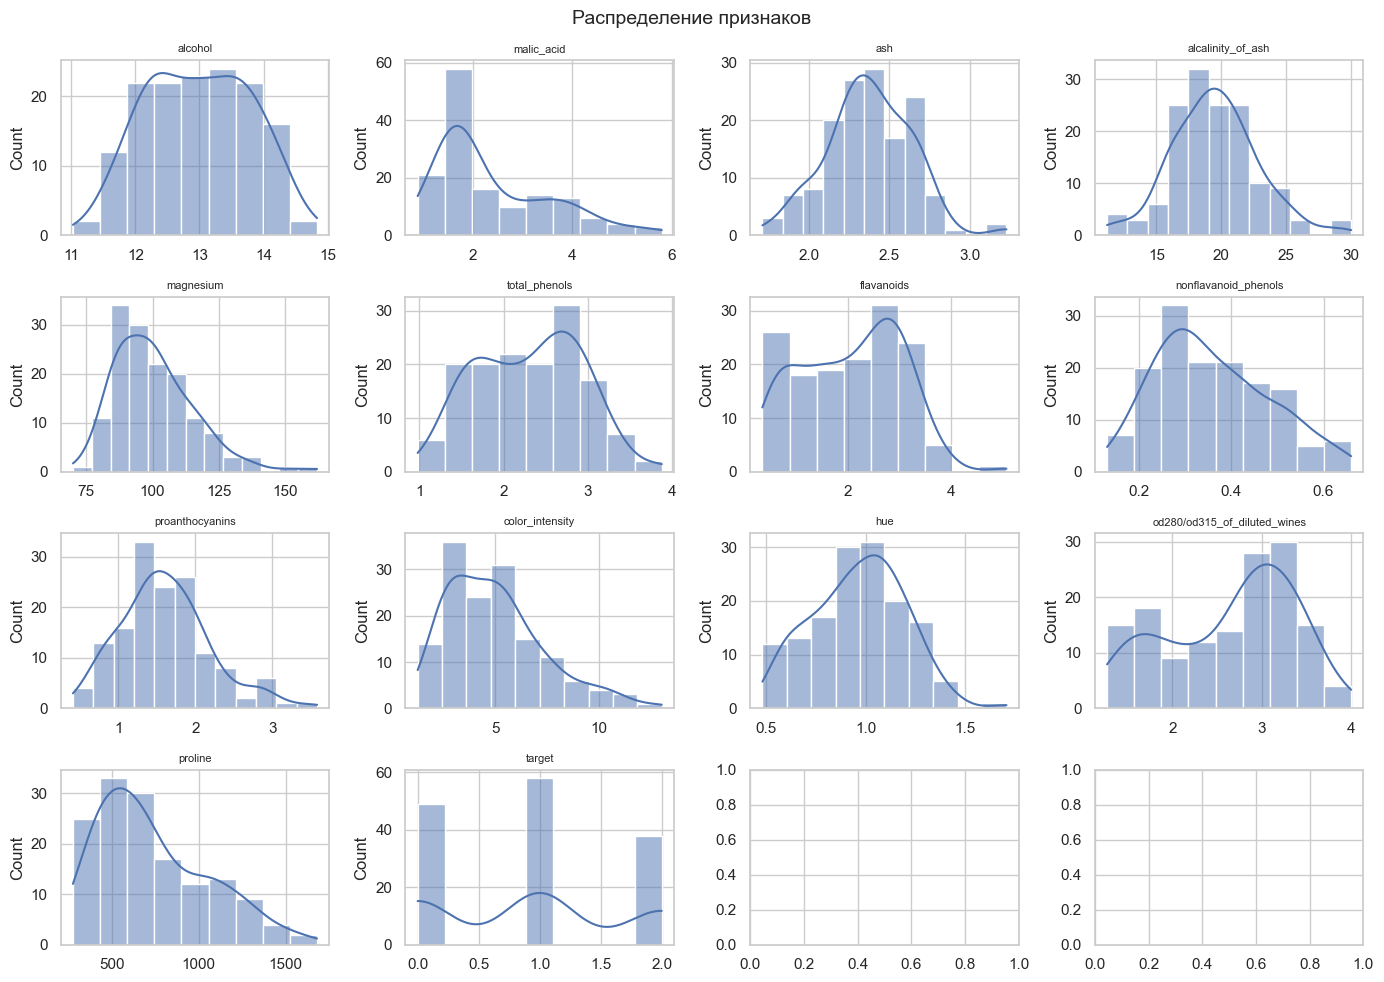

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):  # кроме target
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Распределение признаков', fontsize=14)
plt.tight_layout()
plt.show()

# график 2: ящики с усами (boxplot)

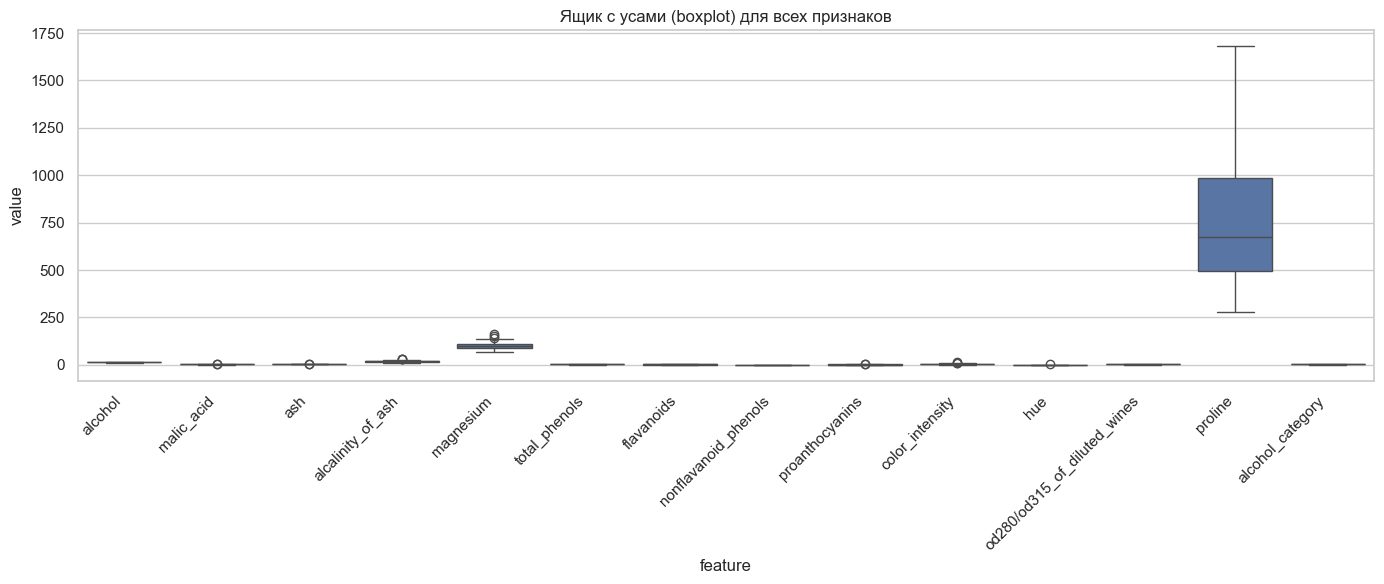

In [6]:
plt.figure(figsize=(14, 6))
df_melt = df.melt(id_vars=['target'], var_name='feature', value_name='value')
sns.boxplot(x='feature', y='value', data=df_melt)
plt.xticks(rotation=45, ha='right')
plt.title('Ящик с усами (boxplot) для всех признаков')
plt.tight_layout()
plt.show()

# график 3: тепловая карта корреляций

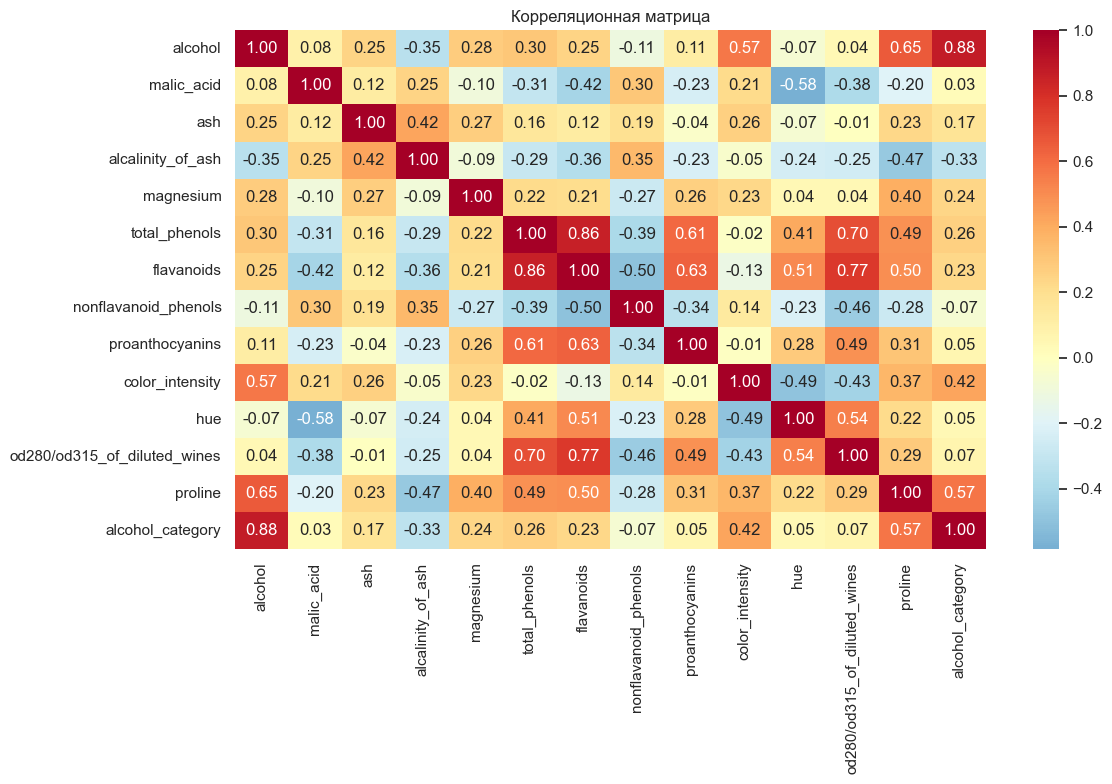

In [7]:
plt.figure(figsize=(12, 8))
corr = df.drop('target', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

# график 4 (требование к группе): диаграмма рассеяния

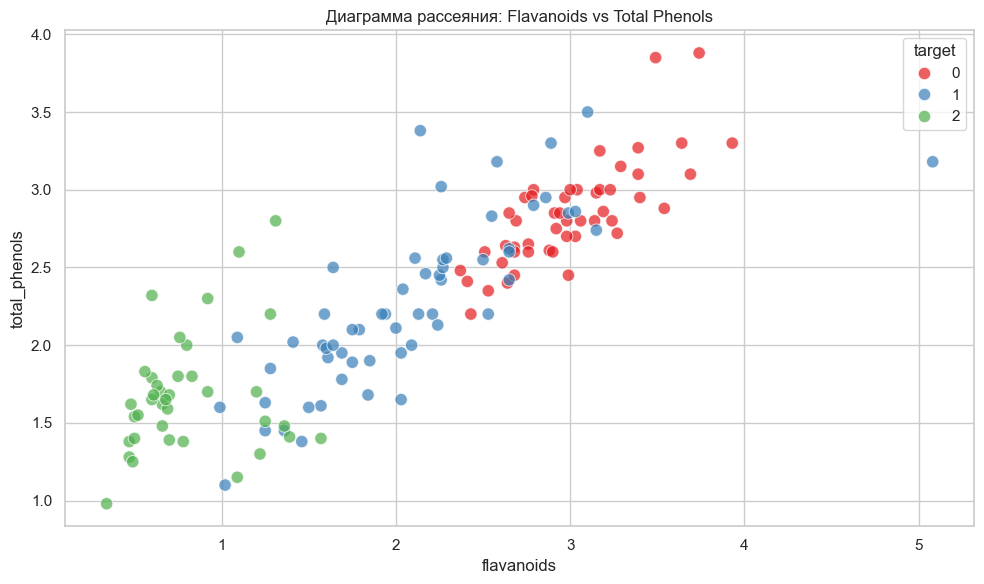

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='flavanoids', y='total_phenols', hue='target', 
                palette='Set1', s=80, alpha=0.7)
plt.title('Диаграмма рассеяния: Flavanoids vs Total Phenols')
plt.tight_layout()
plt.show()

# Выводы

In [9]:
print("="*70)
print("ВЫВОДЫ ПО ЗАДАЧЕ №4 (РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ)")
print("="*70)

# 1. Данные после очистки
print(f"""
1. ОБРАБОТКА ДАННЫХ:
   - Исходный размер Wine dataset: 178 строк, 13 признаков + target
   - Созданы искусственные пропуски (10% в malic_acid, 5% в alcohol_category)
   - После удаления строк с пропусками осталось: {df.shape[0]} строк, {df.shape[1]} столбцов
   - Удалено строк: {178 - df.shape[0]} ({((178 - df.shape[0])/178)*100:.1f}%)
""")

# 2. Корреляционный анализ
corr_matrix = df.drop('target', axis=1).corr()
# Находим максимальную корреляцию (не считая диагональ)
max_corr = -1
max_pair = ("", "")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > max_corr:
            max_corr = abs(corr_matrix.iloc[i, j])
            max_pair = (corr_matrix.columns[i], corr_matrix.columns[j])

print(f"""
2. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:
   - Максимальная корреляция между признаками: {max_pair[0]} ↔ {max_pair[1]} = {max_corr:.3f}
   - Вывод: Высокая корреляция указывает на мультиколлинеарность,
     при построении линейных моделей один из этих признаков можно исключить.
""")

# 3. Анализ выбросов (по IQR)
outlier_info = ""
for col in ['malic_acid', 'proline']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
        outlier_info += f"     • {col}: {outliers} выбросов ({outliers/len(df)*100:.1f}%)\n"

print(f"""
3. АНАЛИЗ ВЫБРОСОВ (по boxplot):
{outlier_info}
""")

# 4. Анализ диаграммы рассеяния
# Получаем средние значения flavanoids и total_phenols по классам
means = df.groupby('target')[['flavanoids', 'total_phenols']].mean()
print(f"""
4. ДИАГРАММА РАССЕЯНИЯ (flavanoids vs total_phenols) - требование группы ИУ5Ц-81Б:
   - Средние значения по сортам вина:
     • Класс 0: flavanoids = {means.loc[0, 'flavanoids']:.2f}, total_phenols = {means.loc[0, 'total_phenols']:.2f}
     • Класс 1: flavanoids = {means.loc[1, 'flavanoids']:.2f}, total_phenols = {means.loc[1, 'total_phenols']:.2f}
     • Класс 2: flavanoids = {means.loc[2, 'flavanoids']:.2f}, total_phenols = {means.loc[2, 'total_phenols']:.2f}
   - Вывод: Признаки flavanoids и total_phenols хорошо разделяют классы вин,
     особенно класс 0 (высокие значения) и класс 2 (низкие значения).
""")

# 5. Общий вывод
print(f"""
5. ОБЩИЙ ВЫВОД:
   - Датасет пригоден для построения моделей машинного обучения.
   - Целевая переменная (сорт вина) имеет 3 класса.
   - Рекомендуемые признаки для модели: flavanoids, total_phenols, proline, od280/od315.
   - Рекомендуемая предобработка: масштабирование (StandardScaler).
""")

ВЫВОДЫ ПО ЗАДАЧЕ №4 (РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ)

1. ОБРАБОТКА ДАННЫХ:
   - Исходный размер Wine dataset: 178 строк, 13 признаков + target
   - Созданы искусственные пропуски (10% в malic_acid, 5% в alcohol_category)
   - После удаления строк с пропусками осталось: 145 строк, 15 столбцов
   - Удалено строк: 33 (18.5%)


2. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:
   - Максимальная корреляция между признаками: alcohol ↔ alcohol_category = 0.880
   - Вывод: Высокая корреляция указывает на мультиколлинеарность,
     при построении линейных моделей один из этих признаков можно исключить.


3. АНАЛИЗ ВЫБРОСОВ (по boxplot):
     • malic_acid: 2 выбросов (1.4%)
     • proline: 0 выбросов (0.0%)



4. ДИАГРАММА РАССЕЯНИЯ (flavanoids vs total_phenols) - требование группы ИУ5Ц-81Б:
   - Средние значения по сортам вина:
     • Класс 0: flavanoids = 3.00, total_phenols = 2.84
     • Класс 1: flavanoids = 2.08, total_phenols = 2.26
     • Класс 2: flavanoids = 0.81, total_phenols = 1.68
   - Вывод: Признаки flavanoid